# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** [Input Nama]
- **Email:** [Input Email]
- **ID Dicoding:** [Input Username]

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from glob import glob
from tqdm import tqdm

import tensorflow.keras.backend as K

import kagglehub
from kagglehub import KaggleDatasetAdapter

import random
import os
import shutil

import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt


## Data Preparation

### Data Loading

In [2]:
!kaggle datasets download -d orvile/inme-veri-seti-stroke-dataset

Dataset URL: https://www.kaggle.com/datasets/orvile/inme-veri-seti-stroke-dataset
License(s): other
100% 991M/991M [00:03<00:00, 273MB/s]



In [3]:
!unzip -q inme-veri-seti-stroke-dataset.zip -d stroke_dataset

Proses ini menghasilkan struktur folder berdasarkan label kelas, yaitu:
* ‘İskemi/PNG’ untuk citra stroke iskemik,
* ‘Kanama/PNG’ untuk stroke hemoragik, dan
* ‘İnme Yok/PNG’ untuk citra normal.

iskemik menghambat oksigen, sedangkan hemoragik menyebabkan perdarahan dan tekanan tinggi di otak

### Data Preprocessing

#### 1. Membuat dataset baru

In [4]:
import os
import shutil

# path dataset asli
src_base = "stroke_dataset/İNME VERİ SETİ"

# path output baru
dst_base = "dataset_clean"

# mapping label
mapping = {
    "İskemi": "Iskemik",
    "Kanama": "Hemoragik",
    "İnme Yok": "Normal"
}

# ekstensi file
png_ext = (".png", ".jpg", ".jpeg")
overlay_ext = (".png", ".jpg", ".jpeg")

for src_folder, dst_folder in mapping.items():

    src_path = os.path.join(src_base, src_folder)

    if not os.path.exists(src_path):
        print(f"❌ Folder tidak ditemukan: {src_path}")
        continue

    # buat struktur folder tujuan
    dst_png = os.path.join(dst_base, dst_folder, "PNG")
    dst_overlay = os.path.join(dst_base, dst_folder, "OVERLAY")

    os.makedirs(dst_png, exist_ok=True)
    os.makedirs(dst_overlay, exist_ok=True)

    for root, dirs, files in os.walk(src_path):
        for file in files:

            src_file = os.path.join(root, file)
            file_lower = file.lower()

            # PNG IMAGE
            if file_lower.endswith(png_ext) and "overlay" not in root.lower():
                new_name = f"{dst_folder}_{file}"
                shutil.copy(src_file, os.path.join(dst_png, new_name))

            # OVERLAY / MASK
            elif file_lower.endswith(png_ext) and "overlay" in root.lower():
                new_name = f"{dst_folder}_{file}"
                shutil.copy(src_file, os.path.join(dst_overlay, new_name))

    print(f"✅ {dst_folder} selesai!")

print("Dataset clean berhasil dibuat dengan struktur lengkap!")

✅ Iskemik selesai!
✅ Hemoragik selesai!
✅ Normal selesai!
Dataset clean berhasil dibuat dengan struktur lengkap!


##### Melihat dataset PNG

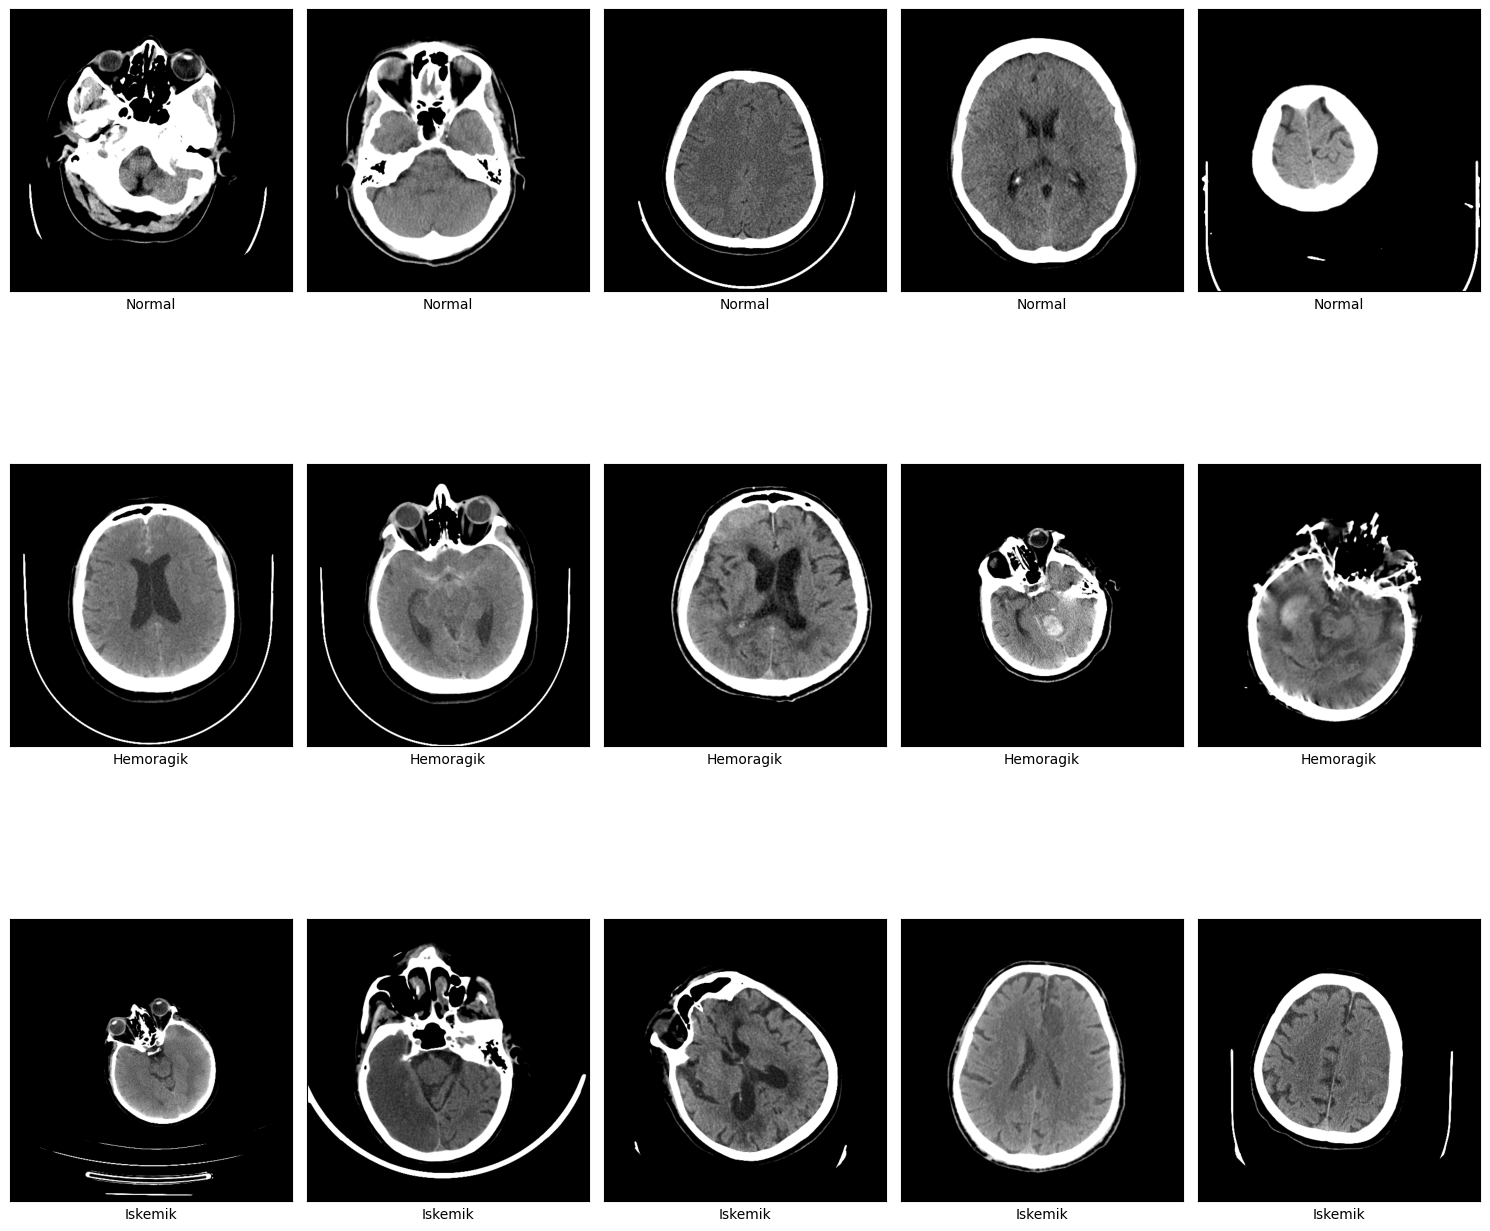

In [5]:
folder_dataset_base = "/content/dataset_clean"
png_dataset = {}

for class_name in os.listdir(folder_dataset_base):
    # The actual PNG images are in a 'PNG' subfolder within each class folder
    class_png_dir = os.path.join(folder_dataset_base, class_name, "PNG")
    if os.path.exists(class_png_dir):
        png_dataset[class_name] = [f for f in os.listdir(class_png_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# If no images are found, prevent further errors
if not png_dataset:
    print("No image data found to display. Please check the dataset path and structure.")
else:
    fig, axs = plt.subplots(len(png_dataset), 5, figsize=(15, 15))

    # Handle case where there's only one class to avoid indexing errors with axs
    if len(png_dataset) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, class_name in enumerate(png_dataset.keys()):
        # Ensure there are enough images to sample, or handle fewer than 5
        images_in_class = png_dataset[class_name]
        if not images_in_class:
            print(f"No images in class: {class_name}")
            # Set the axis to blank or display a message if no images
            for j in range(5):
                axs[i, j].set_visible(False) # Hide empty subplots
            continue

        num_samples = min(5, len(images_in_class))
        if num_samples == 0:
            print(f"Skipping class {class_name} due to no images.")
            # Set the axis to blank or display a message if no images
            for j in range(5):
                axs[i, j].set_visible(False) # Hide empty subplots
            continue

        images = np.random.choice(images_in_class, num_samples, replace=False)

        for j, image_name in enumerate(images):
            img_path = os.path.join(folder_dataset_base, class_name, "PNG", image_name)
            try:
                img = Image.open(img_path)
                axs[i, j].imshow(img)
                axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])
            except FileNotFoundError:
                print(f"Error: Image file not found at {img_path}")
                axs[i, j].set_visible(False)
            except Exception as e:
                print(f"Error opening image {img_path}: {e}")
                axs[i, j].set_visible(False)

        # If fewer than 5 images were displayed, hide the remaining subplots in the row
        for j in range(num_samples, 5):
            axs[i, j].set_visible(False)

    fig.tight_layout()

##### Melihat dataset OVERLAY

No images in class: Normal


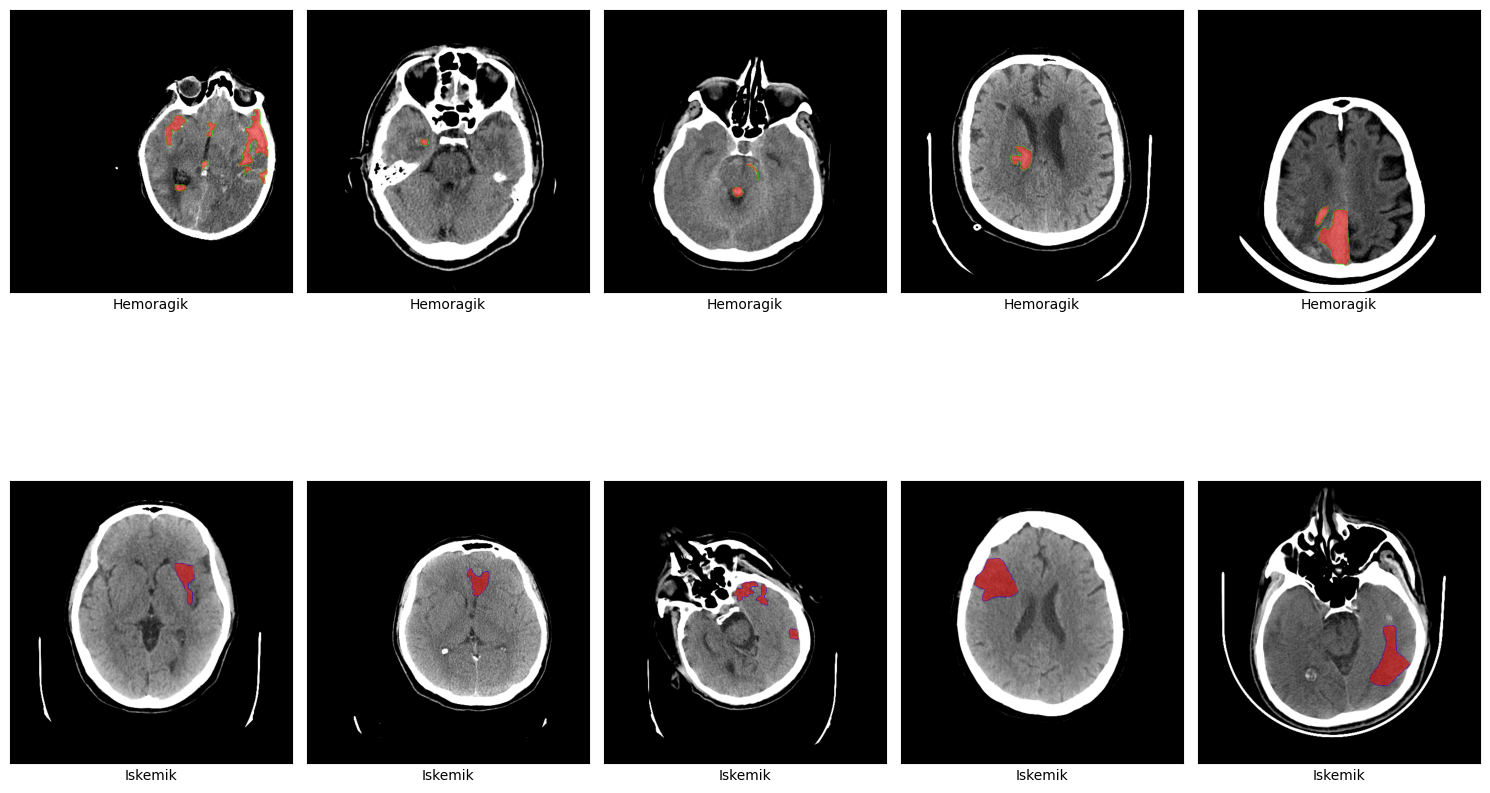

In [6]:
folder_dataset_base = "/content/dataset_clean"
overlay_dataset = {}

for class_name in os.listdir(folder_dataset_base):
    # The actual overlay images are in a 'overlay' subfolder within each class folder
    overlay_dir = os.path.join(folder_dataset_base, class_name, "OVERLAY")
    if os.path.exists(overlay_dir):
        overlay_dataset[class_name] = [f for f in os.listdir(overlay_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# If no images are found, prevent further errors
if not overlay_dataset:
    print("No image data found to display. Please check the dataset path and structure.")
else:
    fig, axs = plt.subplots(len(overlay_dataset), 5, figsize=(15, 15))

    # Handle case where there's only one class to avoid indexing errors with axs
    if len(overlay_dataset) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, class_name in enumerate(overlay_dataset.keys()):
        # Ensure there are enough images to sample, or handle fewer than 5
        images_in_class = overlay_dataset[class_name]
        if not images_in_class:
            print(f"No images in class: {class_name}")
            # Set the axis to blank or display a message if no images
            for j in range(5):
                axs[i, j].set_visible(False) # Hide empty subplots
            continue

        num_samples = min(5, len(images_in_class))
        if num_samples == 0:
            print(f"Skipping class {class_name} due to no images.")
            # Set the axis to blank or display a message if no images
            for j in range(5):
                axs[i, j].set_visible(False) # Hide empty subplots
            continue

        images = np.random.choice(images_in_class, num_samples, replace=False)

        for j, image_name in enumerate(images):
            img_path = os.path.join(folder_dataset_base, class_name, "OVERLAY", image_name)
            try:
                img = Image.open(img_path)
                axs[i, j].imshow(img)
                axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])
            except FileNotFoundError:
                print(f"Error: Image file not found at {img_path}")
                axs[i, j].set_visible(False)
            except Exception as e:
                print(f"Error opening image {img_path}: {e}")
                axs[i, j].set_visible(False)

        # If fewer than 5 images were displayed, hide the remaining subplots in the row
        for j in range(num_samples, 5):
            axs[i, j].set_visible(False)

    fig.tight_layout()

Setiap gambar akan dibaca dan disimpan ke dalam DataFrame berisi:
- Path lengkap file
- Label klasifikasi:
  * ‘İskemi/PNG’ untuk citra stroke iskemik,
  * ‘Kanama/PNG’ untuk stroke hemoragik, dan
  * ‘İnme Yok/PNG’ untuk citra normal.

#### Undersampling

In [7]:
import os
import random
import shutil
import cv2
import numpy as np

base_dir = "dataset_clean"
output_dir = "dataset_balanced"

classes = ["Hemoragik", "Iskemik", "Normal"]
TARGET_PER_CLASS = 1000
IMG_SIZE = (224, 224)

for cls in classes:
    print(f"\n📂 Processing {cls}")

    img_dir = os.path.join(base_dir, cls, "PNG")
    mask_dir = os.path.join(base_dir, cls, "OVERLAY")

    out_img_dir = os.path.join(output_dir, cls, "PNG")
    out_mask_dir = os.path.join(output_dir, cls, "OVERLAY")

    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_mask_dir, exist_ok=True)

    img_files = os.listdir(img_dir)

    # CASE 1: ADA MASK
    if os.path.exists(mask_dir) and len(os.listdir(mask_dir)) > 0:
        mask_files = set(os.listdir(mask_dir))
        img_files = set(img_files)

        common_files = list(img_files & mask_files)

    # CASE 2: NORMAL (NO MASK)
    else:
        common_files = img_files

    print("Total data:", len(common_files))

    # undersampling
    if len(common_files) < TARGET_PER_CLASS:
        selected = common_files
    else:
        selected = random.sample(common_files, TARGET_PER_CLASS)

    for fname in selected:
        img_path = os.path.join(img_dir, fname)
        out_img_path = os.path.join(out_img_dir, fname)

        # copy image
        shutil.copy(img_path, out_img_path)

        # MASK HANDLING
        if cls == "Normal":
            # bikin mask kosong
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, IMG_SIZE)

            blank_mask = np.zeros_like(img)

            cv2.imwrite(os.path.join(out_mask_dir, fname), blank_mask)

        else:
            # copy mask biasa
            shutil.copy(
                os.path.join(mask_dir, fname),
                os.path.join(out_mask_dir, fname)
            )

    print(f"✅ {cls} selesai:", len(selected))


📂 Processing Hemoragik
Total data: 1093
✅ Hemoragik selesai: 1000

📂 Processing Iskemik
Total data: 1130
✅ Iskemik selesai: 1000

📂 Processing Normal
Total data: 4551
✅ Normal selesai: 1000


####  Menggabungkan dataset PNG dan OVERLAY



In [8]:
sample_dir = "/content/dataset_balanced"
def get_paths(sample_dir):
    image_paths = []
    mask_paths = []

    # Hemoragik & Iskemik (ADA OVERLAY MERAH)
    for cls in ['Hemoragik', 'Iskemik']:
        png_dir = os.path.join(sample_dir, cls, 'PNG')
        overlay_dir = os.path.join(sample_dir, cls, 'OVERLAY')

        for file in os.listdir(png_dir):
            if file.lower().endswith('.png'):
                image_paths.append(os.path.join(png_dir, file))
                mask_paths.append(os.path.join(overlay_dir, file))

    # Normal (TIDAK ADA MASK → HITAM)
    normal_dir = os.path.join(sample_dir, 'Normal', 'PNG')
    for file in os.listdir(normal_dir):
        if file.lower().endswith('.png'):
            image_paths.append(os.path.join(normal_dir, file))
            mask_paths.append(None)

    return image_paths, mask_paths

#### Membuat Data Generator

In [9]:
class DataGen(Sequence):
    def __init__(self, img_paths, mask_paths, batch_size=8, size=(224,224)):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.size = size

    def __len__(self):
        return len(self.img_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_img = self.img_paths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_mask = self.mask_paths[idx*self.batch_size:(idx+1)*self.batch_size]

        X = np.zeros((self.batch_size, 224, 224, 3), dtype=np.float32)
        Y = np.zeros((self.batch_size, 224, 224, 1), dtype=np.float32)

        for i, (img_path, mask_path) in enumerate(zip(batch_img, batch_mask)):

            # ================= IMAGE =================
            img = cv2.imread(img_path)
            # Ensure image is 3 channels, convert to RGB
            if img.ndim == 2: # If image is grayscale (2D array)
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            elif img.ndim == 3 and img.shape[2] == 4: # If image is RGBA
                img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
            elif img.ndim == 3 and img.shape[2] == 3: # If image is BGR
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # If it's already RGB or other 3 channel format, it remains as is

            img = cv2.resize(img, self.size) / 255.0
            X[i] = img

            # ================= MASK =================
            if mask_path is not None and os.path.exists(mask_path):

                # FIX: AMBIL WARNA MERAH SAJA
                mask = cv2.imread(mask_path)
                mask = cv2.cvtColor(mask, cv2.COLOR_BGR2HSV)

                lower_red1 = np.array([0, 100, 100])
                upper_red1 = np.array([10, 255, 255])

                lower_red2 = np.array([160, 100, 100])
                upper_red2 = np.array([180, 255, 255])

                mask1 = cv2.inRange(mask, lower_red1, upper_red1)
                mask2 = cv2.inRange(mask, lower_red2, upper_red2)

                mask = mask1 + mask2

                mask = cv2.resize(mask, self.size)
                mask = mask / 255.0

            else:
                # NORMAL → MASK HITAM
                mask = np.zeros(self.size)

            Y[i,...,0] = mask

        return X, Y

#### Split Dataset

In [10]:
base_dir = "/content/dataset_balanced"
img_paths, mask_paths = get_paths(base_dir)

train_img, temp_img, train_mask, temp_mask = train_test_split(
    img_paths, mask_paths, test_size=0.2, random_state=42
)

val_img, test_img, val_mask, test_mask = train_test_split(
    temp_img, temp_mask, test_size=0.5, random_state=42
)

print("Train:", len(train_img))
print("Val:", len(val_img))
print("Test:", len(test_img))

Train: 2400
Val: 300
Test: 300


## Modelling

In [11]:
def conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x

def unet():
    inputs = tf.keras.Input((224,224,3)) # Reverted to 3 channels to match DataGen output

    # encoder
    c1 = conv_block(inputs, 32)
    p1 = tf.keras.layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = tf.keras.layers.MaxPooling2D()(c2)

    # bottleneck
    c3 = conv_block(p2, 128)

    # decoder
    u1 = tf.keras.layers.UpSampling2D()(c3)
    u1 = tf.keras.layers.concatenate([u1, c2])
    c4 = conv_block(u1, 64)

    u2 = tf.keras.layers.UpSampling2D()(c4)
    u2 = tf.keras.layers.concatenate([u2, c1])
    c5 = conv_block(u2, 32)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(c5)

    return tf.keras.Model(inputs, outputs)

In [12]:
train_gen = DataGen(train_img, train_mask, batch_size=8)
val_gen   = DataGen(val_img, val_mask, batch_size=8)
test_gen  = DataGen(test_img, test_mask, batch_size=8)

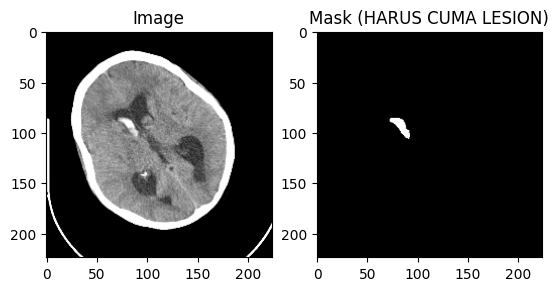

In [13]:
X, Y = train_gen[0]

plt.subplot(1,2,1)
plt.imshow(X[0].squeeze(), cmap='gray')
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(Y[0].squeeze(), cmap='gray')
plt.title("Mask (HARUS CUMA LESION)")
plt.show()

In [14]:
model = unet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 112, 112,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 112, 112,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 112, 112,  │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 224, 224,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 224, 224,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 224, 224,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 224, 224,  │      9,248 │ conv2d_8[0][0]  

 Total params: 471,553 (1.80 MB)

 Trainable params: 471,553 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

## Evaluasi dan Visualisasi

In [15]:
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    intersection = tf.reduce_sum(y_true * y_pred)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

In [16]:
model.compile(optimizer='adam', loss=bce_dice_loss, metrics=['accuracy'])
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    steps_per_epoch=len(train_gen),
    validation_steps=len(val_gen)
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


300/300 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step - accuracy: 0.9883 - dice_coef: 0.0779 - iou: 0.0410 - loss: 0.9913 - val_accuracy: 0.9889 - val_dice_coef: 0.1110 - val_iou: 0.0593 - val_loss: 0.9480
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.9878 - dice_coef: 0.0946 - iou: 0.0503 - loss: 0.9615 - val_accuracy: 0.9890 - val_dice_coef: 0.1406 - val_iou: 0.0762 - val_loss: 0.9168
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step - accuracy: 0.9847 - dice_coef: 0.1892 - iou: 0.1115 - loss: 0.8726 - val_accuracy: 0.9872 - val_dice_coef: 0.2901 - val_iou: 0.1840 - val_loss: 0.7760
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 96ms/step - accuracy: 0.9883 - dice_coef: 0.2689 - iou: 0.1677 - loss: 0.7887 - val_accuracy: 0.9891 - val_dice_coef: 0.3750 - val_iou: 0.2479 - val_loss: 0.6893
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.9881 - dice_coef: 0.3006 - iou: 0.1918 - loss: 0.7541 - val_accuracy: 0.9886 - val_dice_coef: 0.3801 - val_iou: 0.2498

In [17]:
model.evaluate(test_gen)

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9910 - dice_coef: 0.4869 - iou: 0.3391 - loss: 0.5569


[0.5569318532943726,
 0.9909650683403015,
 0.4868735671043396,
 0.33910417556762695]

## Konversi Model

In [19]:
# SAVE SEGMENTATION MODEL (.keras)
model.save('/content/seg_model.keras')

from google.colab import files
files.download('/content/seg_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference (Optional) / KODE LAMA

✅ Model Loaded (tf.keras.models.load_model)


Saving Iskemik_10003.png to Iskemik_10003 (2).png

🔍 Processing: Iskemik_10003 (2).png


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step


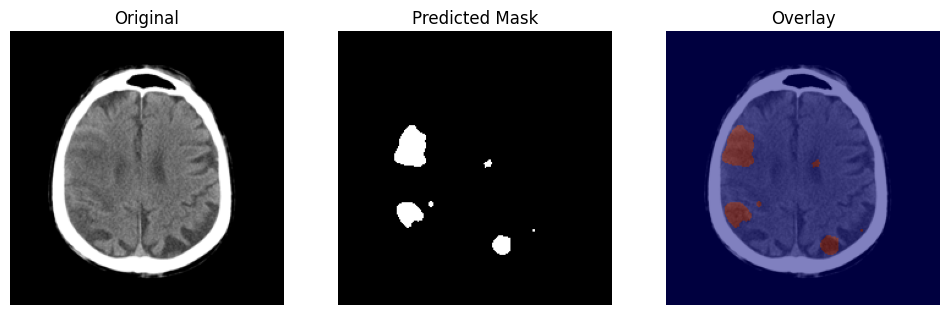

In [28]:
# =========================
# 1. IMPORT
# =========================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import cv2
import tensorflow.keras.backend as K

# =========================
# 2. LOAD MODEL (FIX KERAS 3)
# =========================
# Define custom metrics and loss functions for loading
def dice_coef(y_true, y_pred):
  smooth = 1e-6
  y_true = K.flatten(y_true)
  y_pred = K.flatten(y_pred)
  intersection = K.sum(y_true * y_pred)
  coef = (2. * intersection + smooth) / (K.sum(y_true) + K.sum(y_pred) + smooth)
  return coef

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou(y_true, y_pred):
  smooth = 1e-6
  intersection = K.sum(y_true * y_pred)
  iou_score = (intersection + smooth) / (K.sum(y_true + y_pred) - intersection + smooth)
  return iou_score


# Mengganti TFSMLayer dengan load_model untuk file .keras
model = tf.keras.models.load_model(
    "/content/seg_model.keras",
    custom_objects={'dice_loss': dice_loss, 'bce_dice_loss': bce_dice_loss, 'dice_coef': dice_coef, 'iou': iou}
)

print("✅ Model Loaded (tf.keras.models.load_model)")

# =========================
# 3. PREPROCESS
# =========================
def prepare_image(img_path, size=(224,224)):
    img = Image.open(img_path).convert('RGB') # Changed to 'RGB' for 3 channels
    img = img.resize(size)

    img_array = np.array(img, dtype=np.float32) / 255.0
    # Removed np.expand_dims(..., axis=-1) as 'RGB' already provides 3 channels
    img_array = np.expand_dims(img_array, axis=0)

    return img, img_array

# =========================
# 4. UPLOAD
# =========================
uploaded = files.upload()

# =========================
# 5. INFERENCE
# =========================
for filename in uploaded.keys():
    print(f"\n🔍 Processing: {filename}")

    img, img_array = prepare_image(filename)

    # PREDICT (BEDA DI SINI)
    output = model.predict(img_array)

    # ambil tensor output
    pred_mask = output[0]

    # threshold
    pred_mask = (pred_mask > 0.5).astype(np.uint8)

    # smoothing
    pred_mask = cv2.medianBlur(pred_mask.astype(np.uint8), 5)

    # =========================
    # 6. VISUALISASI
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    # Original image might be RGB, imshow with cmap='gray' would be misleading
    # Display as RGB
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(pred_mask.squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.subplot(1,3,3)
    # Overlay expects an RGB image as the base
    plt.imshow(img)
    plt.imshow(pred_mask.squeeze(), cmap='jet', alpha=0.5)
    plt.title("Overlay")
    plt.axis('off')

    plt.show()

✅ Model Loaded (tf.keras.models.load_model)


Saving Iskemik_10038.png to Iskemik_10038 (1).png

🔍 Processing: Iskemik_10038 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step


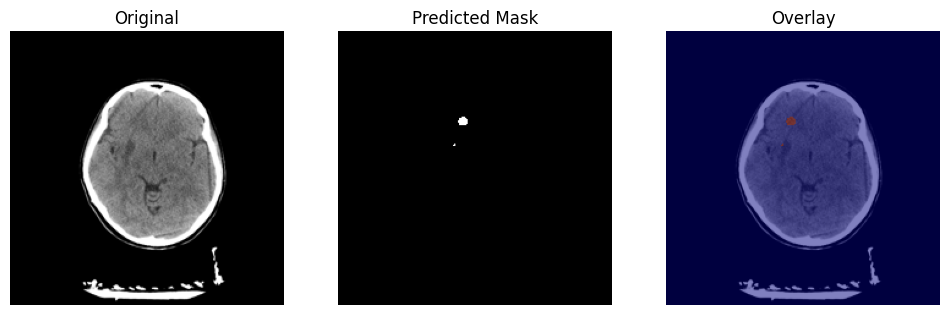

In [31]:
# =========================
# 1. IMPORT
# =========================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import cv2
import tensorflow.keras.backend as K

# =========================
# 2. LOAD MODEL (FIX KERAS 3)
# =========================
# Define custom metrics and loss functions for loading
def dice_coef(y_true, y_pred):
  smooth = 1e-6
  y_true = K.flatten(y_true)
  y_pred = K.flatten(y_pred)
  intersection = K.sum(y_true * y_pred)
  coef = (2. * intersection + smooth) / (K.sum(y_true) + K.sum(y_pred) + smooth)
  return coef

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou(y_true, y_pred):
  smooth = 1e-6
  intersection = K.sum(y_true * y_pred)
  iou_score = (intersection + smooth) / (K.sum(y_true + y_pred) - intersection + smooth)
  return iou_score


# Mengganti TFSMLayer dengan load_model untuk file .keras
model = tf.keras.models.load_model(
    "/content/seg_model.keras",
    custom_objects={'dice_loss': dice_loss, 'bce_dice_loss': bce_dice_loss, 'dice_coef': dice_coef, 'iou': iou}
)

print("✅ Model Loaded (tf.keras.models.load_model)")

# =========================
# 3. PREPROCESS
# =========================
def prepare_image(img_path, size=(224,224)):
    img = Image.open(img_path).convert('RGB') # Changed to 'RGB' for 3 channels
    img = img.resize(size)

    img_array = np.array(img, dtype=np.float32) / 255.0
    # Removed np.expand_dims(..., axis=-1) as 'RGB' already provides 3 channels
    img_array = np.expand_dims(img_array, axis=0)

    return img, img_array

# =========================
# 4. UPLOAD
# =========================
uploaded = files.upload()

# =========================
# 5. INFERENCE
# =========================
for filename in uploaded.keys():
    print(f"\n🔍 Processing: {filename}")

    img, img_array = prepare_image(filename)

    # PREDICT (BEDA DI SINI)
    output = model.predict(img_array)

    # ambil tensor output
    pred_mask = output[0]

    # threshold
    pred_mask = (pred_mask > 0.1).astype(np.uint8)

    # smoothing
    pred_mask = cv2.medianBlur(pred_mask.astype(np.uint8), 5)

    # =========================
    # 6. VISUALISASI
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    # Original image might be RGB, imshow with cmap='gray' would be misleading
    # Display as RGB
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(pred_mask.squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.subplot(1,3,3)
    # Overlay expects an RGB image as the base
    plt.imshow(img)
    plt.imshow(pred_mask.squeeze(), cmap='jet', alpha=0.5)
    plt.title("Overlay")
    plt.axis('off')

    plt.show()

✅ Model Loaded (tf.keras.models.load_model)


Saving Normal_10000.png to Normal_10000.png

🔍 Processing: Normal_10000.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step


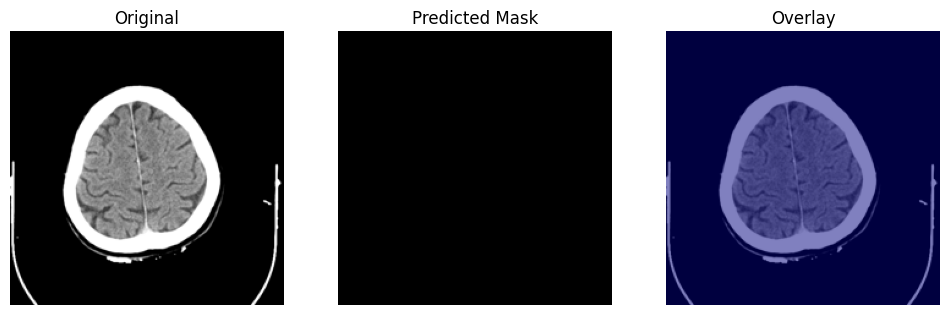

In [25]:
# =========================
# 1. IMPORT
# =========================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import cv2
import tensorflow.keras.backend as K

# =========================
# 2. LOAD MODEL (FIX KERAS 3)
# =========================
# Define custom metrics and loss functions for loading
def dice_coef(y_true, y_pred):
  smooth = 1e-6
  y_true = K.flatten(y_true)
  y_pred = K.flatten(y_pred)
  intersection = K.sum(y_true * y_pred)
  coef = (2. * intersection + smooth) / (K.sum(y_true) + K.sum(y_pred) + smooth)
  return coef

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou(y_true, y_pred):
  smooth = 1e-6
  intersection = K.sum(y_true * y_pred)
  iou_score = (intersection + smooth) / (K.sum(y_true + y_pred) - intersection + smooth)
  return iou_score


# Mengganti TFSMLayer dengan load_model untuk file .keras
model = tf.keras.models.load_model(
    "/content/seg_model.keras",
    custom_objects={'dice_loss': dice_loss, 'bce_dice_loss': bce_dice_loss, 'dice_coef': dice_coef, 'iou': iou}
)

print("✅ Model Loaded (tf.keras.models.load_model)")

# =========================
# 3. PREPROCESS
# =========================
def prepare_image(img_path, size=(224,224)):
    img = Image.open(img_path).convert('RGB') # Changed to 'RGB' for 3 channels
    img = img.resize(size)

    img_array = np.array(img, dtype=np.float32) / 255.0
    # Removed np.expand_dims(..., axis=-1) as 'RGB' already provides 3 channels
    img_array = np.expand_dims(img_array, axis=0)

    return img, img_array

# =========================
# 4. UPLOAD
# =========================
uploaded = files.upload()

# =========================
# 5. INFERENCE
# =========================
for filename in uploaded.keys():
    print(f"\n🔍 Processing: {filename}")

    img, img_array = prepare_image(filename)

    # PREDICT (BEDA DI SINI)
    output = model.predict(img_array)

    # ambil tensor output
    pred_mask = output[0]

    # threshold
    pred_mask = (pred_mask > 0.1).astype(np.uint8)

    # smoothing
    pred_mask = cv2.medianBlur(pred_mask.astype(np.uint8), 5)

    # =========================
    # 6. VISUALISASI
# =========================
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    # Original image might be RGB, imshow with cmap='gray' would be misleading
    # Display as RGB
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(pred_mask.squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.subplot(1,3,3)
    # Overlay expects an RGB image as the base
    plt.imshow(img)
    plt.imshow(pred_mask.squeeze(), cmap='jet', alpha=0.5)
    plt.title("Overlay")
    plt.axis('off')

    plt.show()